Data Loading and Preprocessing


We will use the Hugging Face IMDB dataset for 1D CNN based sentiment classification.


In [ ]:
!uv pip install datasets matplotlib


In [ ]:
import os
import re
from collections import Counter
import matplotli
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset


In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MAX_VOCAB = 20000
BATCH_SIZE = 64

print(f"Device: {DEVICE}")


Device: cuda


In [3]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    return re.findall(r"\b\w+\b", text)


def load_imdb():
    print("Downloading/Loading Hugging Face IMDB dataset...")
    dataset = load_dataset("imdb")
    train_texts = dataset["train"]["text"]
    train_labels = dataset["train"]["label"]
    test_texts = dataset["test"]["text"]
    test_labels = dataset["test"]["label"]
    return train_texts, train_labels, test_texts, test_labels


In [4]:
train_texts, train_labels, test_texts, test_labels = load_imdb()
print(f"Train samples: {len(train_texts)}")
print(f"Test samples: {len(test_texts)}")
print(train_texts[0][:500])


Downloading/Loading Hugging Face IMDB dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train samples: 25000
Test samples: 25000
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attent


In [5]:
def build_vocab(texts, max_vocab):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))
    most_common = counter.most_common(max_vocab - 2)
    word2idx = {"<PAD>": 0, "<UNK>": 1}
    for word, _ in most_common:
        word2idx[word] = len(word2idx)
    return word2idx


def encode(text, word2idx):
    tokens = tokenize(text)
    return [word2idx.get(token, 1) for token in tokens]


In [6]:
word2idx = build_vocab(train_texts, MAX_VOCAB)
vocab_size = len(word2idx)
print(f"Vocab size: {vocab_size}")


Vocab size: 20000


We use token indexing with padding to construct minibatches for the CNN model.


In [7]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, word2idx):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = encode(self.texts[idx], self.word2idx)
        y = self.labels[idx]
        return x, y


def collate_fn(batch):
    sequences = [torch.tensor(item[0], dtype=torch.long) for item in batch]
    labels = torch.tensor([item[1] for item in batch], dtype=torch.long)

    padded_sequences = nn.utils.rnn.pad_sequence(
        sequences, batch_first=True, padding_value=0
    )

    if padded_sequences.size(1) < 5:
        pad_amount = 5 - padded_sequences.size(1)
        padded_sequences = nn.functional.pad(padded_sequences, (0, pad_amount), value=0)

    return padded_sequences, labels


In [8]:
train_ds = IMDBDataset(train_texts, train_labels, word2idx)
test_ds = IMDBDataset(test_texts, test_labels, word2idx)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    pin_memory=True,
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    collate_fn=collate_fn,
    pin_memory=True,
)


Model Definition


In [9]:
class TextCNN1D(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim=128,
        num_filters=100,
        kernel_sizes=(3, 4, 5),
        num_classes=2,
        dropout=0.5,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList(
            [nn.Conv1d(embed_dim, num_filters, kernel_size) for kernel_size in kernel_sizes]
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        conv_outs = [torch.relu(conv(x)).max(dim=2).values for conv in self.convs]
        x = torch.cat(conv_outs, dim=1)
        x = self.dropout(x)
        return self.fc(x)


Training


In [10]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total


In [25]:
model = TextCNN1D(vocab_size).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 4
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
    te_loss, te_acc = evaluate(model, test_loader, criterion)
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["test_loss"].append(te_loss)
    history["test_acc"].append(te_acc)
    print(
        f"Epoch {epoch}/{EPOCHS}  "
        f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  "
        f"test_loss={te_loss:.4f}  test_acc={te_acc:.4f}"
    )


Epoch 1/4  train_loss=0.6213  train_acc=0.6649  test_loss=0.4314  test_acc=0.8069
Epoch 2/4  train_loss=0.4635  train_acc=0.7808  test_loss=0.3471  test_acc=0.8529
Epoch 3/4  train_loss=0.3727  train_acc=0.8332  test_loss=0.3330  test_acc=0.8522
Epoch 4/4  train_loss=0.3154  train_acc=0.8660  test_loss=0.3050  test_acc=0.8706


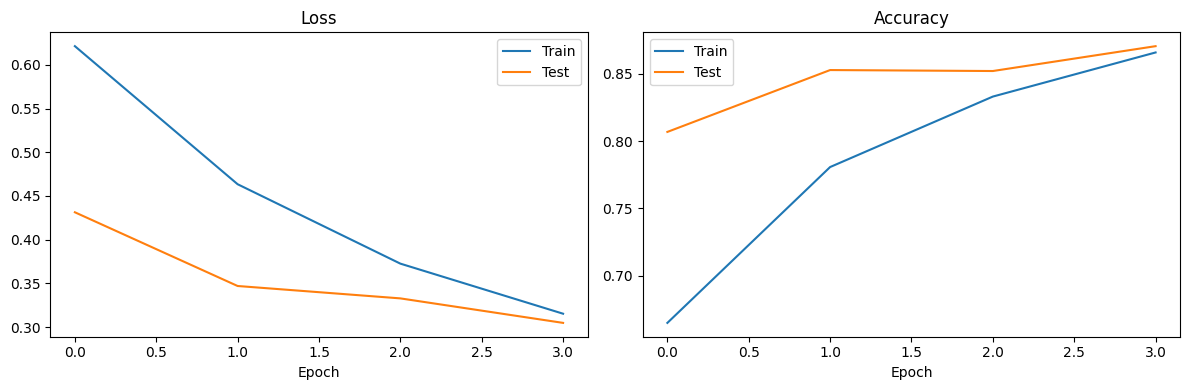

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["test_loss"], label="Test")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["test_acc"], label="Test")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


In [27]:
model.eval()
samples = test_texts[:10]
sample_labels = test_labels[:10]
predictions = []

with torch.no_grad():
    for text in samples:
        ids = torch.tensor([encode(text, word2idx)], dtype=torch.long).to(DEVICE)
        if ids.size(1) < 5:
            ids = nn.functional.pad(ids, (0, 5 - ids.size(1)), value=0)
        logits = model(ids)
        pred = logits.argmax(dim=1).item()
        predictions.append(pred)

label_map = {0: "negative", 1: "positive"}
print(f"Final Test Accuracy: {history['test_acc'][-1]:.4f}\n")
for i, (text, true, pred) in enumerate(zip(samples, sample_labels, predictions), start=1):
    print(f"--- Sample {i} ---")
    print(f"Text: {text[:200]}...")
    print(f"True: {label_map[true]}  |  Predicted: {label_map[pred]}\n")


Final Test Accuracy: 0.8706

--- Sample 1 ---
Text: I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Bab...
True: negative  |  Predicted: negative

--- Sample 2 ---
Text: Worth the entertainment value of a rental, especially if you like action movies. This one features the usual car chases, fights with the great Van Damme kick style, shooting battles with the 40 shell ...
True: negative  |  Predicted: negative

--- Sample 3 ---
Text: its a totally average film with a few semi-alright action sequences that make the plot seem a little better and remind the viewer of the classic van dam films. parts of the plot don't make sense and s...
True: negative  |  Predicted: negative

--- Sample 4 ---
Text: STAR RATING: ***** Saturday Night **** Friday Night *** Friday Morning ** Sunday Night * Monday Morning <br /><br />Former New Orleans homicide cop

The 1D CNN achieves an accuracy of around 85% on the test set.